In [11]:
# Import des fonctions et bibliothèques
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from Convolution import *

# Configuration de l'affichage
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

In [3]:
import urllib.request
import os

# Créer le dossier images s'il n'existe pas
os.makedirs("images", exist_ok=True)

# Dictionnaire des fichiers disponibles sur ce mirror (coderforlife)
# Les liens pointent directement vers les fichiers bruts (raw) sur GitHub
files = {
    "baboon.png": "https://raw.githubusercontent.com/coderforlife/c4l-image-dataset/master/512x512/mandrill.png",
    "peppers.png": "https://raw.githubusercontent.com/coderforlife/c4l-image-dataset/master/512x512/pepper.png",
    "sailboat.png": "https://raw.githubusercontent.com/coderforlife/c4l-image-dataset/master/512x512/boat.png",
    "airplane.png": "https://raw.githubusercontent.com/coderforlife/c4l-image-dataset/master/512x512/plane.png",
}

print("Téléchargement en cours...")
for name, url in files.items():
    try:
        urllib.request.urlretrieve(url, f"images/{name}")
        print(f"✓ Succès: {name}")
    except Exception as e:
        print(f"✗ Échec pour {name}: {e}")

print("\n✅ Vérifie le dossier 'images/' !")

Téléchargement en cours...
✓ Succès: baboon.png
✓ Succès: peppers.png
✓ Succès: sailboat.png
✓ Succès: airplane.png

✅ Vérifie le dossier 'images/' !


In [5]:
import os

image_dir = "images"
if os.path.exists(image_dir):
    images = os.listdir(image_dir)
    print(f" Dossier '{image_dir}' contient {len(images)} fichier(s):")
    for img in images:
        print(f"   - {img}")
else:
    print(" Dossier 'images' non trouvé")

 Dossier 'images' contient 4 fichier(s):
   - airplane.png
   - baboon.png
   - peppers.png
   - sailboat.png


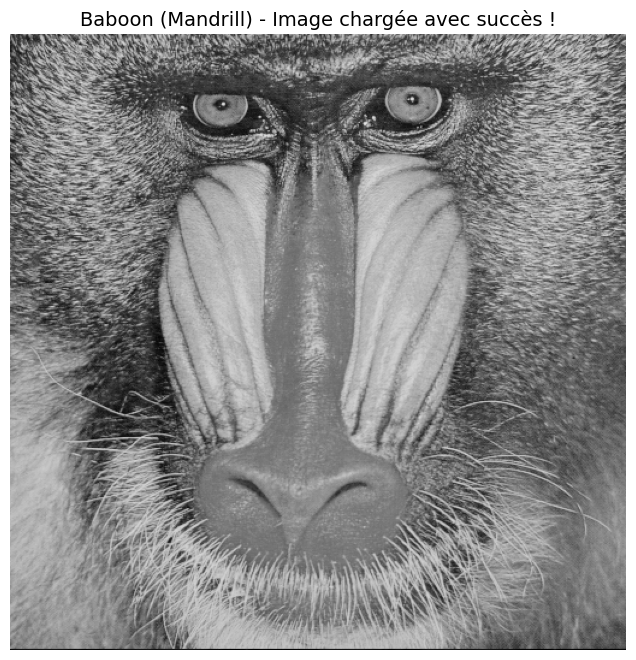

✅ Image chargée - Dimensions: (512, 512, 3)


In [6]:
import cv2
import matplotlib.pyplot as plt

# Charger et afficher Baboon
img = cv2.imread("images/baboon.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("Baboon (Mandrill) - Image chargée avec succès !", fontsize=14)
plt.axis('off')
plt.show()

print(f"✅ Image chargée - Dimensions: {img_rgb.shape}")

In [8]:
# Définir le dossier contenant les images
image_dir = "images"

# Liste des images à tester
image_names = [
    "baboon.png",
    "peppers.png", 
    "sailboat.png",
    "airplane.png"
]

# Charger les images disponibles
available_images = []
for img_name in image_names:
    img_path = os.path.join(image_dir, img_name)
    if os.path.exists(img_path):
        available_images.append(img_path)
        print(f"Image chargée: {img_name}")
    else:
        print(f" Image non trouvée: {img_name}")

print(f"\n {len(available_images)} image(s) disponible(s)")

Image chargée: baboon.png
Image chargée: peppers.png
Image chargée: sailboat.png
Image chargée: airplane.png

 4 image(s) disponible(s)


In [15]:
# Définition de la fonction load_image (si elle manque)
def load_image(image_path, mode='auto'):
    
    img_bgr = cv2.imread(image_path)
    assert img_bgr is not None, f"Erreur: Impossible de charger l'image '{image_path}'"
    
    if mode == 'gray':
        gray_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        return gray_image
    elif mode == 'rgb':
        rgb_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        return rgb_image
    else:  # mode 'auto'
        if len(img_bgr.shape) == 2:
            return img_bgr
        else:
            return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Fonction load_image créée")

Fonction load_image créée


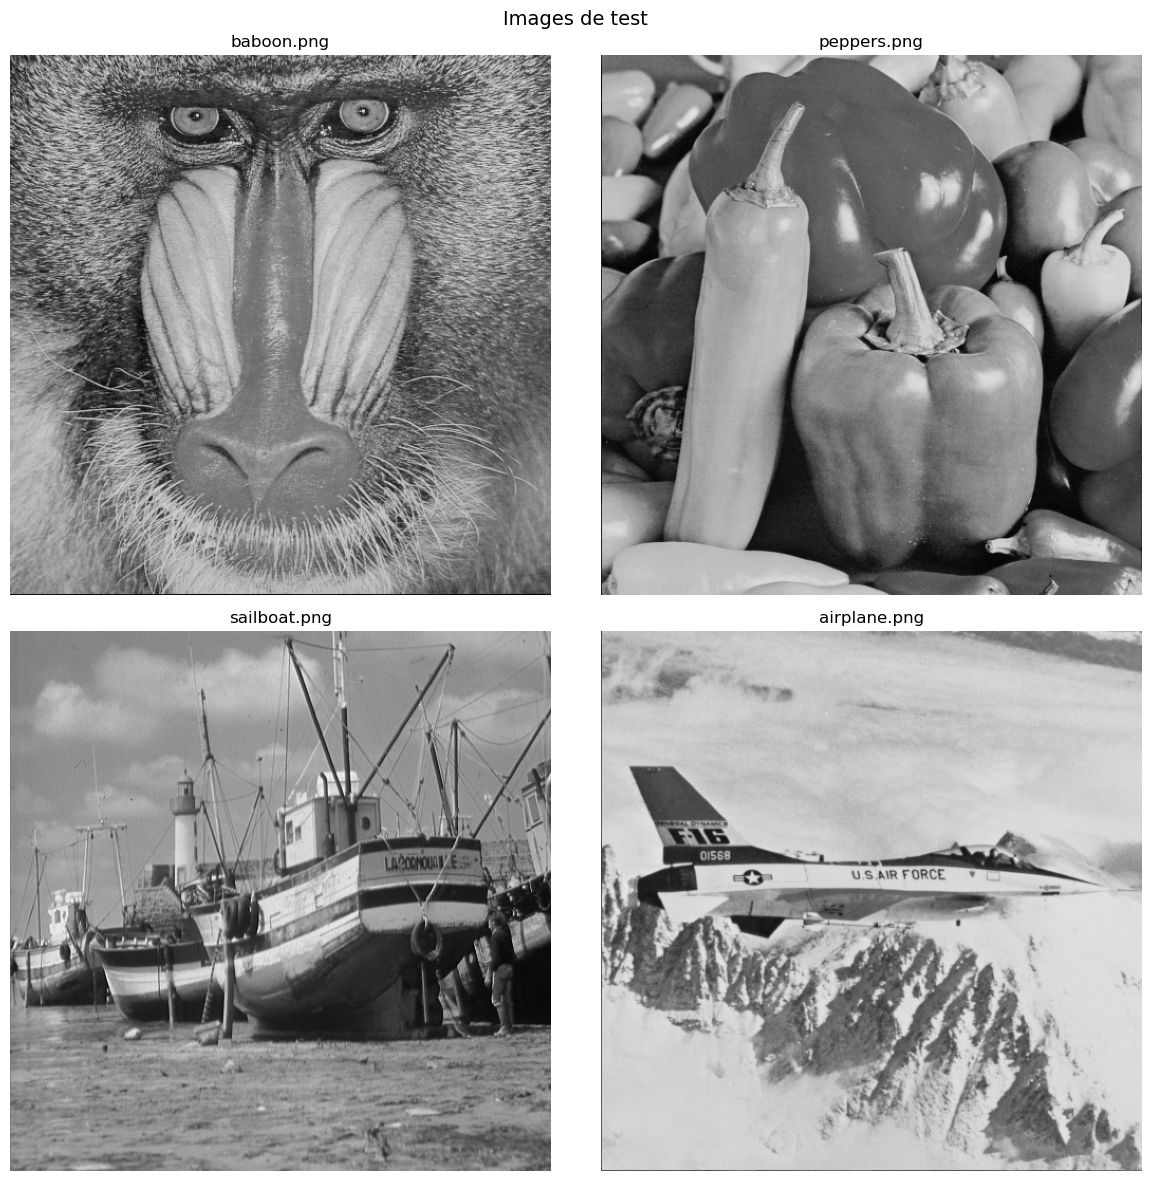

In [16]:
if available_images:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(available_images):
        img = load_image(img_path, mode='rgb')
        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(img_path), fontsize=12)
        axes[idx].axis('off')
    
    plt.suptitle("Images de test", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune image disponible")

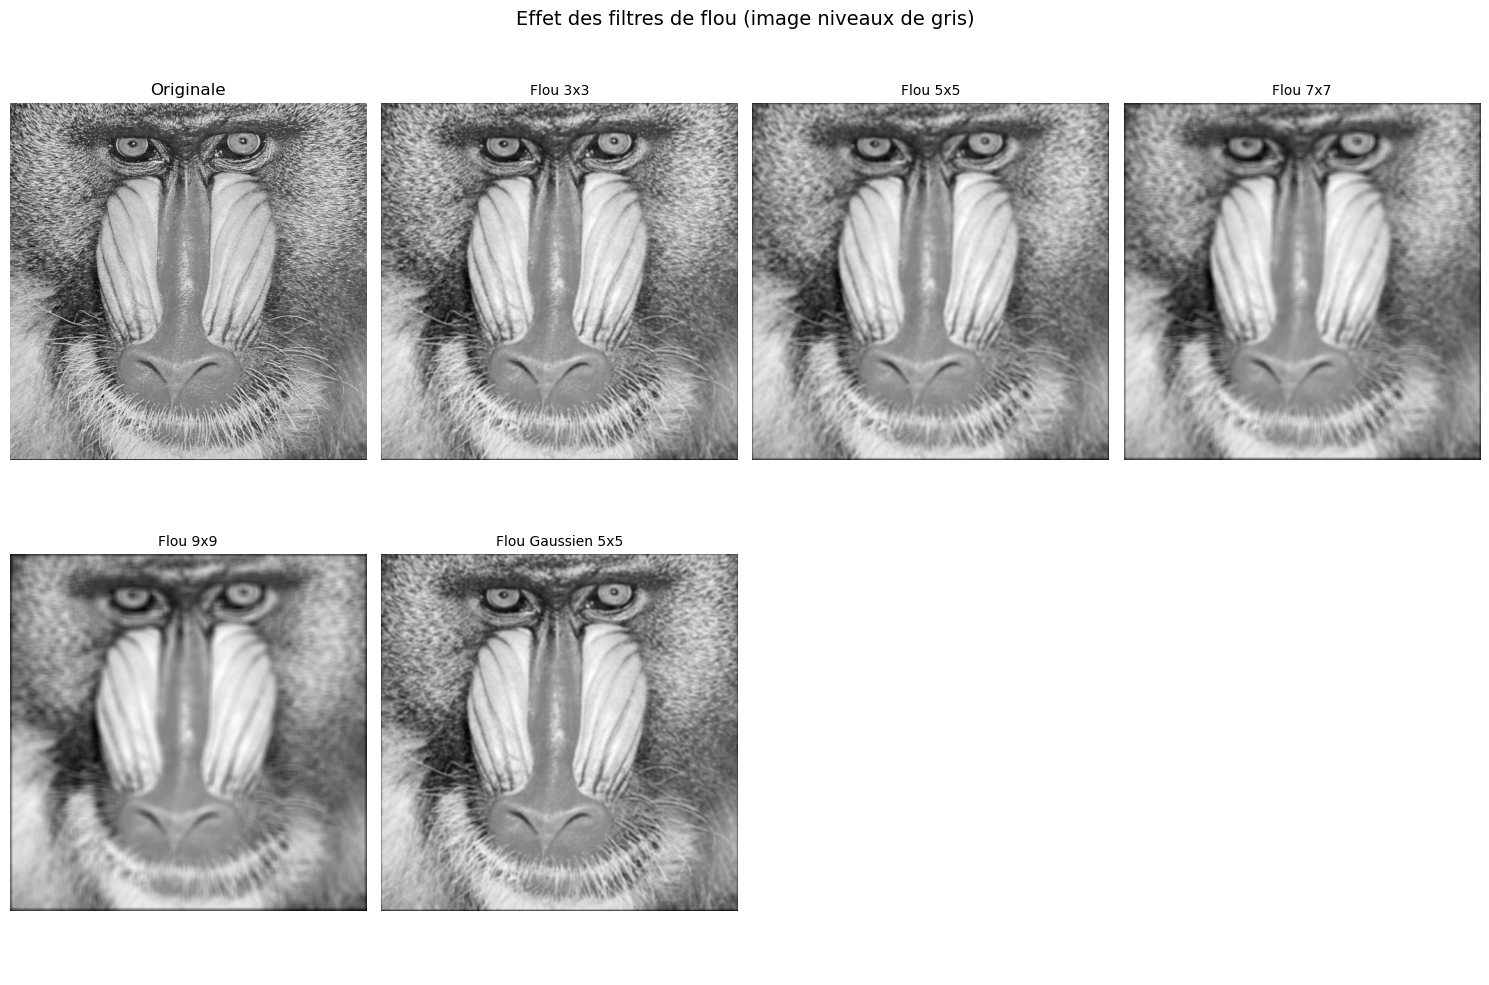


 INTERPRÉTATION:
- Flou 3x3: Flou léger, les détails sont encore visibles
- Flou 5x5: Flou modéré, réduction nette des détails fins
- Flou 7x7: Flou prononcé, l'image devient très lisse
- Flou 9x9: Flou extrême, perte importante des détails
- Flou Gaussien: Transition plus naturelle, préserve mieux les contours


In [17]:
if available_images:
    img_path = available_images[0]  # Baboon
    gray_img = load_image(img_path, mode='gray')
    
    # Appliquer différents flous
    blur_results = {}
    
    blur_3 = apply_convolution(gray_img, create_kernel_blur(3))
    blur_5 = apply_convolution(gray_img, create_kernel_blur(5))
    blur_7 = apply_convolution(gray_img, create_kernel_blur(7))
    blur_9 = apply_convolution(gray_img, create_kernel_blur(9))
    gaussian = apply_convolution(gray_img, create_kernel_gaussian_blur(5, 1.5))
    
    blur_results = {
        'Flou 3x3': blur_3,
        'Flou 5x5': blur_5,
        'Flou 7x7': blur_7,
        'Flou 9x9': blur_9,
        'Flou Gaussien 5x5': gaussian
    }
    
    # Afficher les résultats
    display_comparison_figure(gray_img, blur_results, "Effet des filtres de flou (image niveaux de gris)")
    
    print("\n INTERPRÉTATION:")
    print("- Flou 3x3: Flou léger, les détails sont encore visibles")
    print("- Flou 5x5: Flou modéré, réduction nette des détails fins")
    print("- Flou 7x7: Flou prononcé, l'image devient très lisse")
    print("- Flou 9x9: Flou extrême, perte importante des détails")
    print("- Flou Gaussien: Transition plus naturelle, préserve mieux les contours")

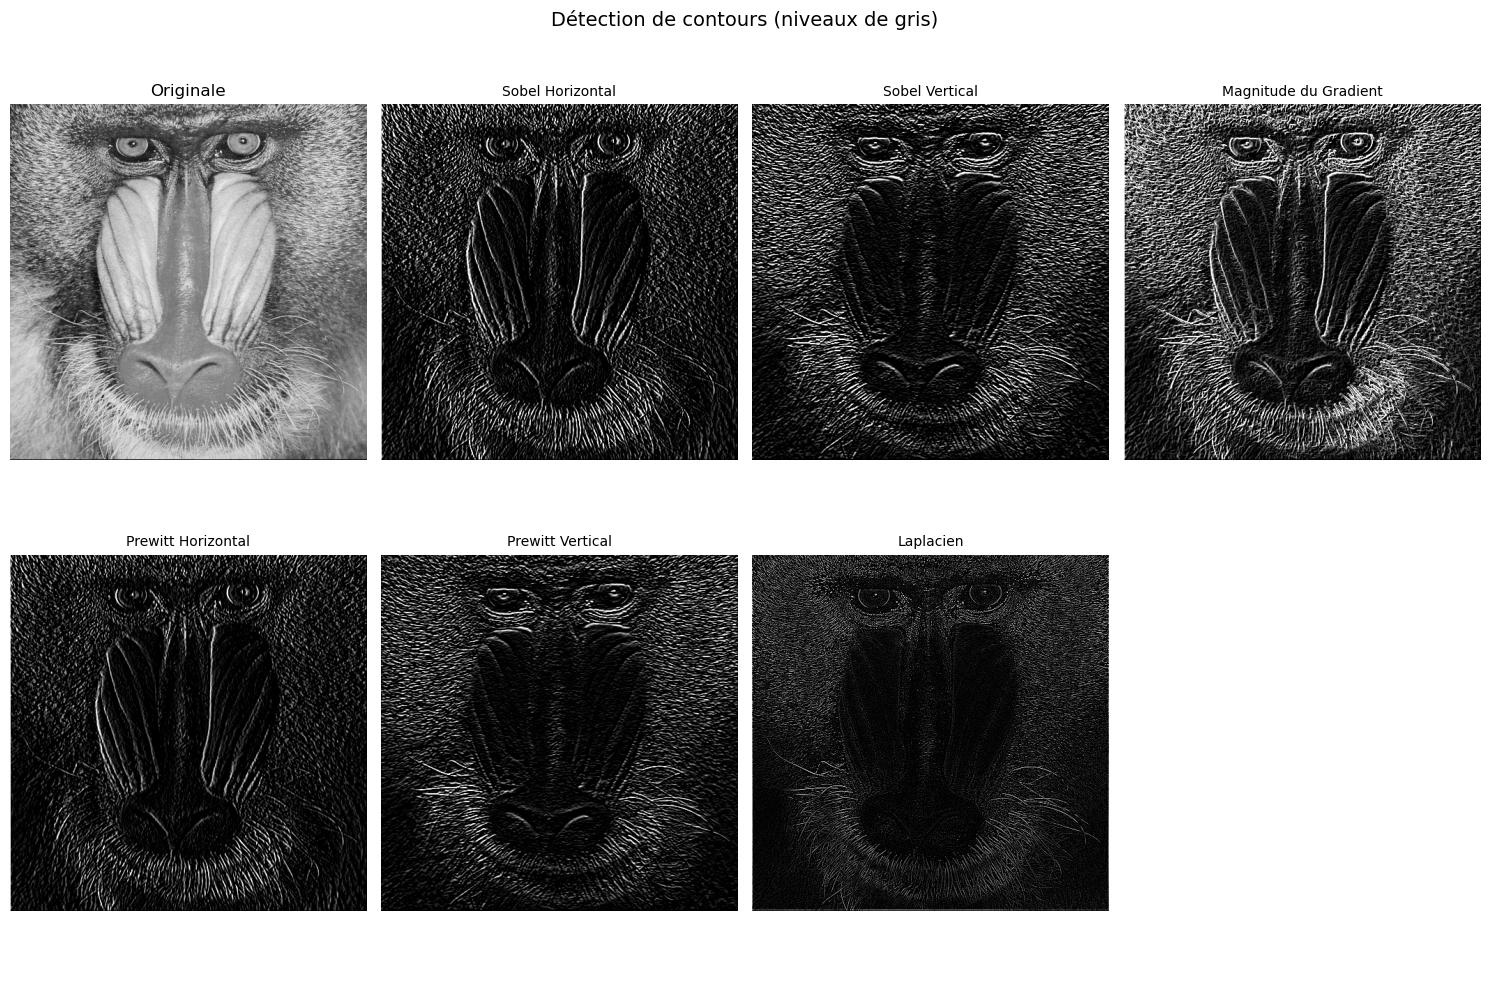


 INTERPRÉTATION:
- Sobel Horizontal: Les contours horizontaux apparaissent clairement
- Sobel Vertical: Les contours verticaux sont mis en évidence
- Magnitude du Gradient: Combine les deux directions pour tous les contours
- Prewitt: Résultat similaire à Sobel mais avec une sensibilité différente
- Laplacien: Détecte les contours dans toutes les directions


In [18]:
if available_images:
    img_path = available_images[0]  # Baboon
    gray_img = load_image(img_path, mode='gray')
    
    # Appliquer les filtres de contours
    sobel_h_gray = apply_convolution(gray_img, create_kernel_sobel_horizontal())
    sobel_v_gray = apply_convolution(gray_img, create_kernel_sobel_vertical())
    prewitt_h_gray = apply_convolution(gray_img, create_kernel_prewitt_horizontal())
    prewitt_v_gray = apply_convolution(gray_img, create_kernel_prewitt_vertical())
    laplacian_gray = apply_convolution(gray_img, create_kernel_laplacian())
    
    # Calculer la magnitude du gradient Sobel
    magnitude_gray = compute_gradient_magnitude(sobel_h_gray, sobel_v_gray)
    
    # Regrouper les résultats
    edge_results_gray = {
        'Sobel Horizontal': sobel_h_gray,
        'Sobel Vertical': sobel_v_gray,
        'Magnitude du Gradient': magnitude_gray,
        'Prewitt Horizontal': prewitt_h_gray,
        'Prewitt Vertical': prewitt_v_gray,
        'Laplacien': laplacian_gray
    }
    
    # Afficher
    display_comparison_figure(gray_img, edge_results_gray, "Détection de contours (niveaux de gris)")
    
    print("\n INTERPRÉTATION:")
    print("- Sobel Horizontal: Les contours horizontaux apparaissent clairement")
    print("- Sobel Vertical: Les contours verticaux sont mis en évidence")
    print("- Magnitude du Gradient: Combine les deux directions pour tous les contours")
    print("- Prewitt: Résultat similaire à Sobel mais avec une sensibilité différente")
    print("- Laplacien: Détecte les contours dans toutes les directions")

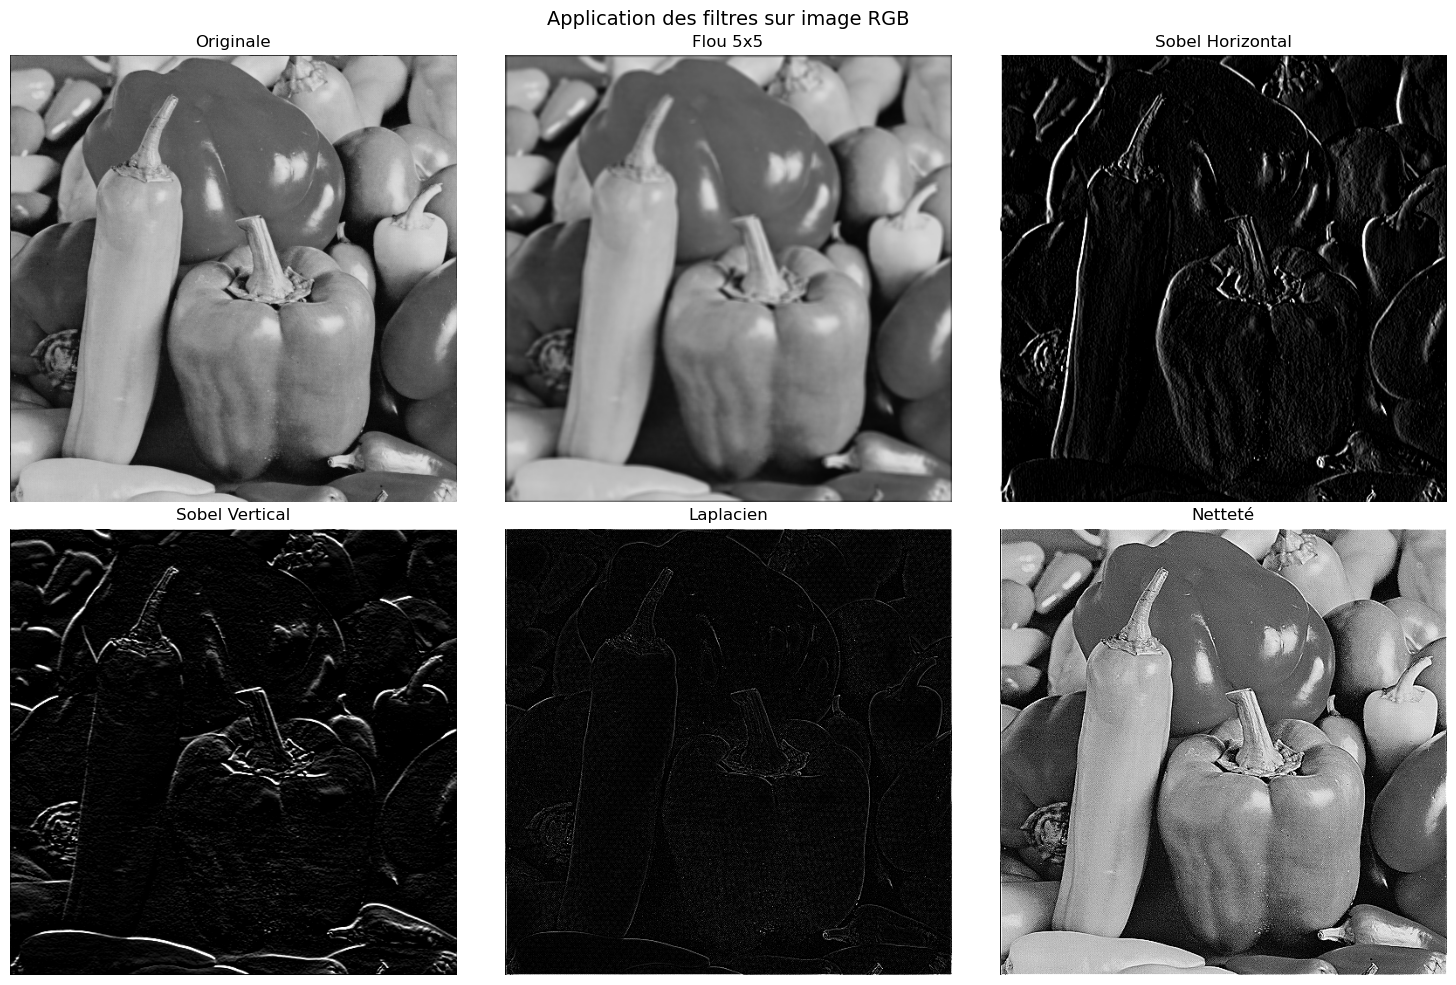


 INTERPRÉTATION:
- Les filtres s'appliquent indépendamment sur chaque canal couleur
- Les contours sont détectés dans les 3 canaux (Rouge, Vert, Bleu)
- L'image RGB donne des contours colorés
- Le filtre netteté rehausse les détails dans toutes les couleurs


In [19]:
if available_images:
    img_path = available_images[1]  # Peppers (image couleur)
    rgb_img = load_image(img_path, mode='rgb')
    
    # Appliquer les filtres sur RGB
    sobel_h_rgb = apply_convolution(rgb_img, create_kernel_sobel_horizontal())
    sobel_v_rgb = apply_convolution(rgb_img, create_kernel_sobel_vertical())
    laplacian_rgb = apply_convolution(rgb_img, create_kernel_laplacian())
    blur_rgb = apply_convolution(rgb_img, create_kernel_blur(5))
    sharpen_rgb = apply_convolution(rgb_img, create_kernel_sharpen())
    
    rgb_results = {
        'Flou 5x5': blur_rgb,
        'Sobel Horizontal': sobel_h_rgb,
        'Sobel Vertical': sobel_v_rgb,
        'Laplacien': laplacian_rgb,
        'Netteté': sharpen_rgb
    }
    
    # Affichage
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    axes[0].imshow(rgb_img)
    axes[0].set_title('Originale', fontsize=12)
    axes[0].axis('off')
    
    for i, (name, img) in enumerate(rgb_results.items()):
        axes[i + 1].imshow(img)
        axes[i + 1].set_title(name, fontsize=12)
        axes[i + 1].axis('off')
    
    plt.suptitle("Application des filtres sur image RGB", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n INTERPRÉTATION:")
    print("- Les filtres s'appliquent indépendamment sur chaque canal couleur")
    print("- Les contours sont détectés dans les 3 canaux (Rouge, Vert, Bleu)")
    print("- L'image RGB donne des contours colorés")
    print("- Le filtre netteté rehausse les détails dans toutes les couleurs")

Noyaux aléatoires générés:

Noyau 3x3:
[[ 0.082 -0.023  0.106]
 [ 0.25  -0.038 -0.038]
 [ 0.259  0.126 -0.077]]

Noyau 5x5 (extrait):
[[ 0.026 -0.007]
 [-0.012  0.081]]

Noyau 7x7 (extrait):
[[ 0.014 -0.004]
 [ 0.021 -0.013]]


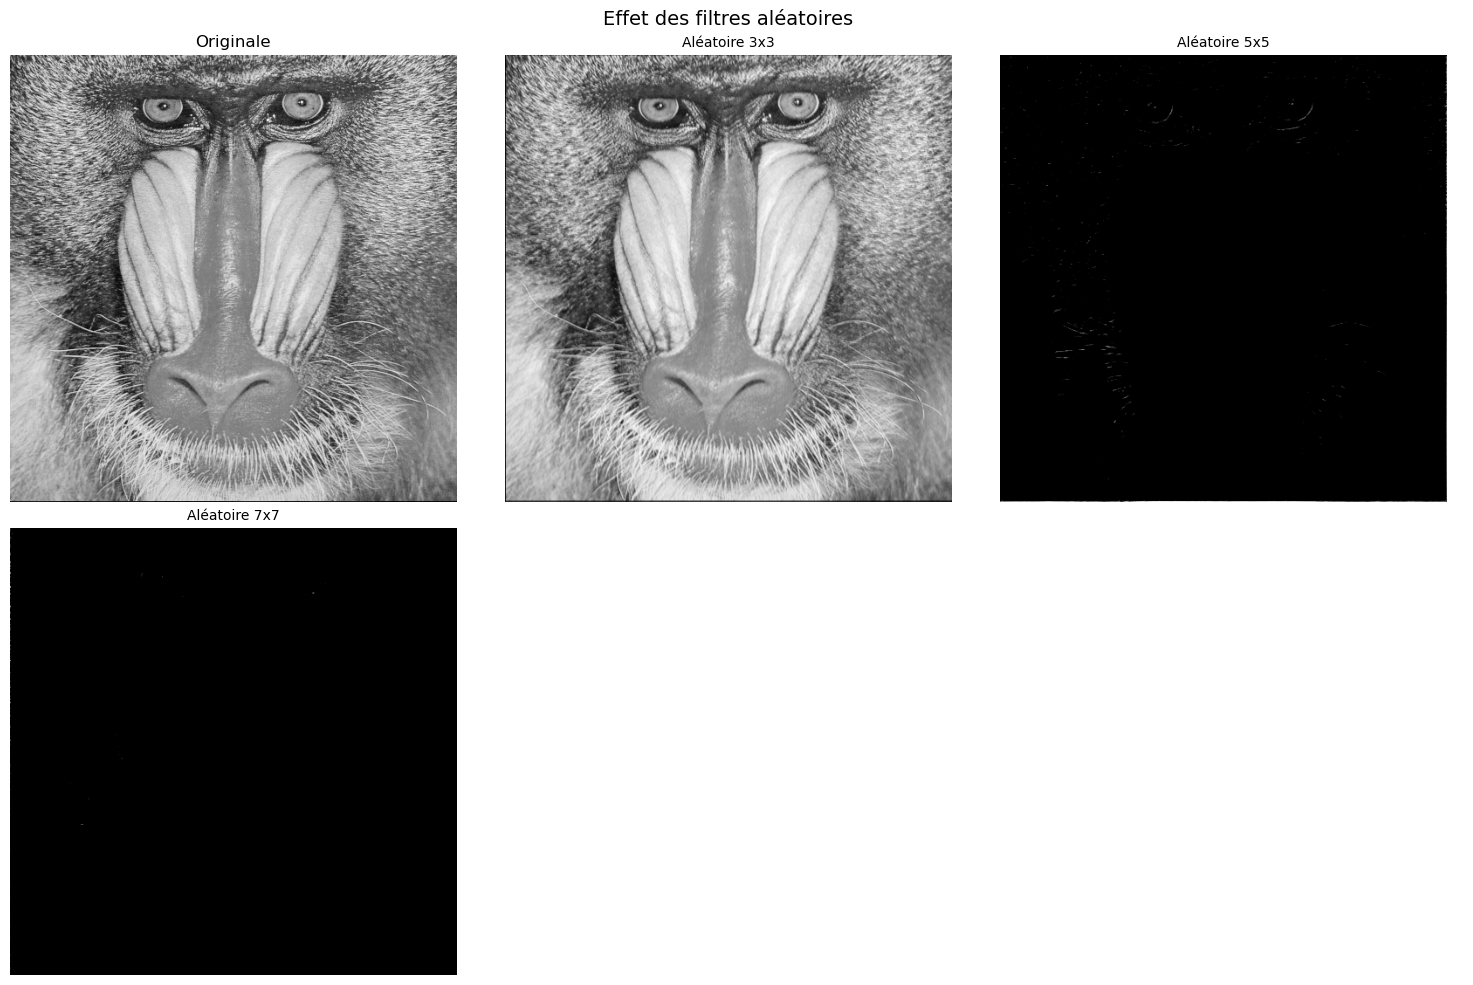


 INTERPRÉTATION:
- Les filtres aléatoires produisent des effets imprévisibles
- Plus le noyau est grand, plus l'effet est prononcé
- L'effet dépend des valeurs positives/négatives du noyau


In [20]:
if available_images:
    img_path = available_images[0]  # Baboon
    gray_img = load_image(img_path, mode='gray')
    
    # Créer des filtres aléatoires
    random_3x3 = create_kernel_random(3, 42)
    random_5x5 = create_kernel_random(5, 42)
    random_7x7 = create_kernel_random(7, 42)
    
    print("Noyaux aléatoires générés:")
    print("\nNoyau 3x3:")
    print(np.round(random_3x3, 3))
    print("\nNoyau 5x5 (extrait):")
    print(np.round(random_5x5[:2, :2], 3))
    print("\nNoyau 7x7 (extrait):")
    print(np.round(random_7x7[:2, :2], 3))
    
    # Appliquer les filtres
    random_results = {
        'Aléatoire 3x3': apply_convolution(gray_img, random_3x3),
        'Aléatoire 5x5': apply_convolution(gray_img, random_5x5),
        'Aléatoire 7x7': apply_convolution(gray_img, random_7x7)
    }
    
    display_comparison_figure(gray_img, random_results, "Effet des filtres aléatoires")
    
    print("\n INTERPRÉTATION:")
    print("- Les filtres aléatoires produisent des effets imprévisibles")
    print("- Plus le noyau est grand, plus l'effet est prononcé")
    print("- L'effet dépend des valeurs positives/négatives du noyau")

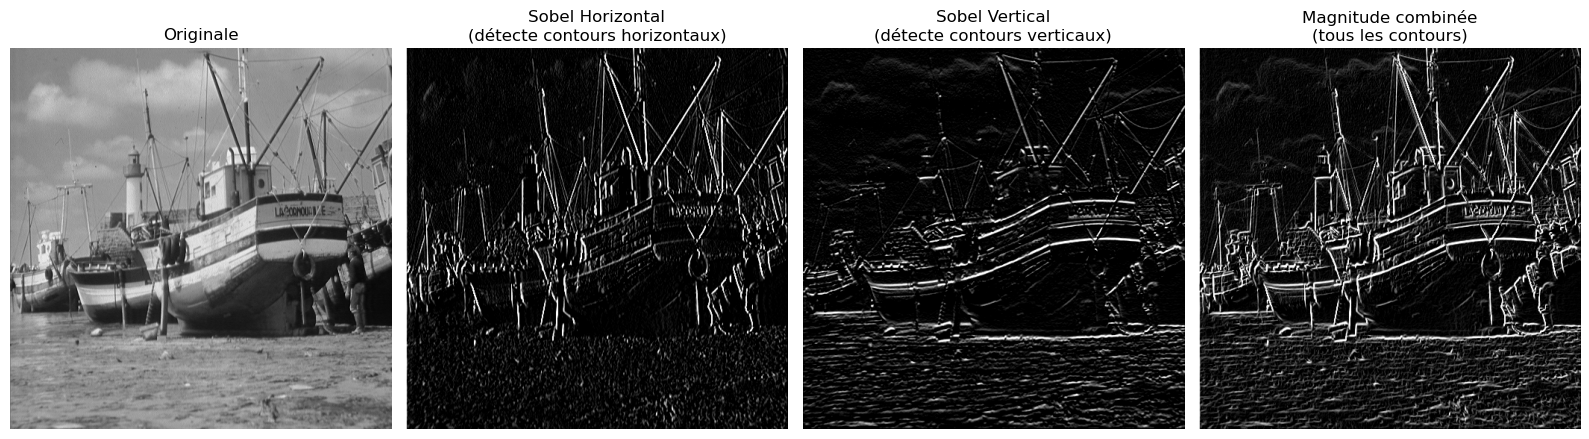


 INTERPRÉTATION:
- Sobel Horizontal: Les contours horizontaux apparaissent en blanc/clair
- Sobel Vertical: Les contours verticaux sont mis en évidence
- La magnitude combine les deux pour une détection complète


In [21]:
if available_images:
    img_path = available_images[2]  # Sailboat
    gray_img = load_image(img_path, mode='gray')
    
    sobel_h = apply_convolution(gray_img, create_kernel_sobel_horizontal())
    sobel_v = apply_convolution(gray_img, create_kernel_sobel_vertical())
    magnitude = compute_gradient_magnitude(sobel_h, sobel_v)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title("Originale", fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(sobel_h, cmap='gray')
    axes[1].set_title("Sobel Horizontal\n(détecte contours horizontaux)", fontsize=12)
    axes[1].axis('off')
    
    axes[2].imshow(sobel_v, cmap='gray')
    axes[2].set_title("Sobel Vertical\n(détecte contours verticaux)", fontsize=12)
    axes[2].axis('off')
    
    axes[3].imshow(magnitude, cmap='gray')
    axes[3].set_title("Magnitude combinée\n(tous les contours)", fontsize=12)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n INTERPRÉTATION:")
    print("- Sobel Horizontal: Les contours horizontaux apparaissent en blanc/clair")
    print("- Sobel Vertical: Les contours verticaux sont mis en évidence")
    print("- La magnitude combine les deux pour une détection complète")

In [22]:
# Sauvegarde de toutes les images filtrées
if available_images:
    os.makedirs("results", exist_ok=True)
    
    for img_path in available_images:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        gray_img = load_image(img_path, mode='gray')
        rgb_img = load_image(img_path, mode='rgb')
        
        # Sauvegarder l'originale
        save_filtered_image(gray_img, f"{base_name}_original_gray.jpg")
        save_filtered_image(rgb_img, f"{base_name}_original_rgb.jpg")
        
        # Sauvegarder différents filtres
        kernels_to_save = {
            'blur_3x3': create_kernel_blur(3),
            'blur_7x7': create_kernel_blur(7),
            'sobel_h': create_kernel_sobel_horizontal(),
            'sobel_v': create_kernel_sobel_vertical(),
            'laplacian': create_kernel_laplacian(),
            'sharpen': create_kernel_sharpen(),
            'random_3x3': create_kernel_random(3, 42)
        }
        
        for name, kernel in kernels_to_save.items():
            result_gray = apply_convolution(gray_img, kernel)
            result_rgb = apply_convolution(rgb_img, kernel)
            save_filtered_image(result_gray, f"{base_name}_gray_{name}.jpg")
            save_filtered_image(result_rgb, f"{base_name}_rgb_{name}.jpg")
        
        print(f" Résultats sauvegardés pour {base_name}")
    
    print(f"\n Toutes les images ont été sauvegardées dans le dossier 'results/'")
    
    # Afficher le contenu du dossier
    results_files = os.listdir("results")
    print(f"\n Dossier 'results/' contient {len(results_files)} fichier(s)")

 Résultats sauvegardés pour baboon
 Résultats sauvegardés pour peppers
 Résultats sauvegardés pour sailboat
 Résultats sauvegardés pour airplane

 Toutes les images ont été sauvegardées dans le dossier 'results/'

 Dossier 'results/' contient 64 fichier(s)
